BEHAVIORAL FEATURES USED FOR SEGMENTATION

Price Behavior (4 features):
  ✓ UnitPrice_mean_x
  ✓ UnitPrice_std_x
  ✓ UnitPrice_min_x
  ✓ UnitPrice_max_x

Sales Behavior (3 features):
  ✓ SalesQty_sum
  ✓ SalesQty_mean
  ✓ SalesQty_std

Revenue Behavior (2 features):
  ✓ ExtPrice_sum
  ✓ ExtPrice_mean

Cost Behavior (3 features):
  ✓ ExtCost_sum
  ✓ ExtCost_mean
  ✓ ExtCost_std

Customer Behavior (2 features):
  ✓ OrdersPerCustomer
  ✓ RevenuePerCustomer

Lifecycle Behavior (2 features):
  ✓ AvgDaysBetweenOrders
  ✓ SalesDate_count

Quote Behavior (4 features):
  ✓ QuoteQty_sum
  ✓ QuoteID_nunique
  ✓ QuoteConversionRate
  ✓ QuoteWinRate

TOTAL FEATURES FOR CLUSTERING: 20

Products after removing missing values: 40359 (from 40359 original)

Performing K-Means clustering with 3 segments...

Calculating performance score using 8 key metrics:
  • Sales Volume: SalesQty_sum, SalesQty_mean
  • Revenue Generation: ExtPrice_sum, ExtPrice_mean
  • Customer Engagement: OrdersPerCustomer, Revenue

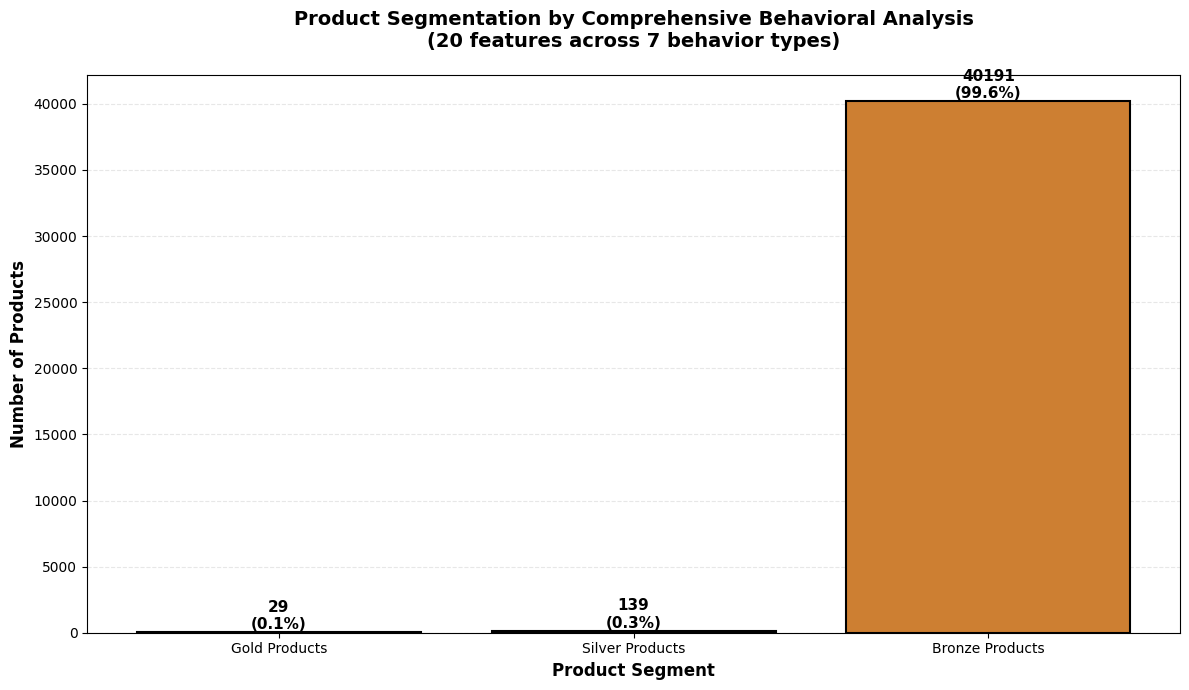


PRODUCT SEGMENTATION SUMMARY
Total Products Analyzed: 40359
Behavioral Dimensions: 7
Total Features Used: 20

Segment Distribution:
  🥇 Gold Products: 29 products (0.1%) - Performance: 0.2537
  🥈 Silver Products: 139 products (0.3%) - Performance: 0.1837
  🥉 Bronze Products: 40191 products (99.6%) - Performance: 0.1244


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
path = r"c:\Users\Araya\Desktop\product_features_enhanced (1).csv"
df = pd.read_csv(path)

# COMPREHENSIVE BEHAVIORAL FEATURE SET
# Organized by behavior type for better understanding
behavioral_features = {
    'Price Behavior': ['UnitPrice_mean_x', 'UnitPrice_std_x', 'UnitPrice_min_x', 'UnitPrice_max_x'],
    'Sales Behavior': ['SalesQty_sum', 'SalesQty_mean', 'SalesQty_std'],
    'Revenue Behavior': ['ExtPrice_sum', 'ExtPrice_mean'],
    'Cost Behavior': ['ExtCost_sum', 'ExtCost_mean', 'ExtCost_std'],
    'Customer Behavior': ['OrdersPerCustomer', 'RevenuePerCustomer'],
    'Lifecycle Behavior': ['AvgDaysBetweenOrders', 'SalesDate_count'],
    'Quote Behavior': ['QuoteQty_sum', 'QuoteID_nunique', 'QuoteConversionRate', 'QuoteWinRate']
}

# Flatten and check which features are available
all_features = []
available_by_category = {}

print("="*70)
print("BEHAVIORAL FEATURES USED FOR SEGMENTATION")
print("="*70)

for behavior_type, features_list in behavioral_features.items():
    available_features = [f for f in features_list if f in df.columns]
    if available_features:
        all_features.extend(available_features)
        available_by_category[behavior_type] = available_features
        print(f"\n{behavior_type} ({len(available_features)} features):")
        for feat in available_features:
            print(f"  ✓ {feat}")
    else:
        print(f"\n{behavior_type}: ⚠ No features available")

print(f"\n{'='*70}")
print(f"TOTAL FEATURES FOR CLUSTERING: {len(all_features)}")
print(f"{'='*70}\n")

# Clean data - only keep rows with all behavioral features
df_clean = df[all_features].dropna().copy()
print(f"Products after removing missing values: {len(df_clean)} (from {len(df)} original)")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# KMeans clustering (3 groups)
print("\nPerforming K-Means clustering with 3 segments...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clean["Cluster"] = clusters

# Calculate COMPREHENSIVE Business Performance Score
# Weight different behavioral categories
performance_components = {
    'Sales Volume': ['SalesQty_sum', 'SalesQty_mean'],
    'Revenue Generation': ['ExtPrice_sum', 'ExtPrice_mean'],
    'Customer Engagement': ['OrdersPerCustomer', 'RevenuePerCustomer'],
    'Conversion Efficiency': ['QuoteConversionRate', 'QuoteWinRate'] if 'QuoteWinRate' in df_clean.columns else ['QuoteConversionRate']
}

# Add profit if available
if 'totalprofit' in df.columns:
    df_clean['totalprofit'] = df.loc[df_clean.index, 'totalprofit']
    performance_components['Profitability'] = ['totalprofit']

# Collect all performance metrics for naming
all_performance_metrics = []
for category, metrics in performance_components.items():
    for metric in metrics:
        if metric in df_clean.columns:
            all_performance_metrics.append(metric)

print(f"\nCalculating performance score using {len(all_performance_metrics)} key metrics:")
for category, metrics in performance_components.items():
    available = [m for m in metrics if m in df_clean.columns]
    if available:
        print(f"  • {category}: {', '.join(available)}")

# Normalize each metric to 0-1 scale
performance_scores = df_clean[all_performance_metrics].copy()
for col in all_performance_metrics:
    min_val = performance_scores[col].min()
    max_val = performance_scores[col].max()
    if max_val > min_val:
        performance_scores[col] = (performance_scores[col] - min_val) / (max_val - min_val)
    else:
        performance_scores[col] = 0

# Calculate average performance score
df_clean['PerformanceScore'] = performance_scores.mean(axis=1)

# Rank clusters by comprehensive performance score
perf_mean = df_clean.groupby("Cluster")["PerformanceScore"].mean().sort_values()
order = perf_mean.index.tolist()

print(f"\n{'='*70}")
print("CLUSTER PERFORMANCE RANKING")
print(f"{'='*70}")
for idx, cluster_id in enumerate(order):
    score = perf_mean[cluster_id]
    tier = 'Bronze' if idx==0 else 'Silver' if idx==1 else 'Gold'
    print(f"  {tier} Tier (Cluster {cluster_id}): Performance Score = {score:.4f}")

# Map clusters to Gold/Silver/Bronze
name_map = {
    order[0]: "Bronze Products",
    order[1]: "Silver Products",
    order[2]: "Gold Products"
}

df_clean["Segment"] = df_clean["Cluster"].map(name_map)

# Count per segment
segment_counts = df_clean["Segment"].value_counts().reindex(["Gold Products", "Silver Products", "Bronze Products"])

# Create beautiful bar chart
plt.figure(figsize=(12, 7))
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze colors
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black', linewidth=1.5)

plt.title(f"Product Segmentation by Comprehensive Behavioral Analysis\n({len(all_features)} features across {len(available_by_category)} behavior types)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Product Segment", fontsize=12, fontweight='bold')
plt.ylabel("Number of Products", fontsize=12, fontweight='bold')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, segment_counts.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val)}\n({val/segment_counts.sum()*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

plt.tight_layout()

# Save
out_path = "product_segment_gold_silver_bronze.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"\n{'='*70}")
print(f"Chart saved to: {out_path}")
print(f"{'='*70}")

# Display the plot
plt.show()

# Print summary
print("\n" + "="*70)
print("PRODUCT SEGMENTATION SUMMARY")
print("="*70)
print(f"Total Products Analyzed: {len(df_clean)}")
print(f"Behavioral Dimensions: {len(available_by_category)}")
print(f"Total Features Used: {len(all_features)}")
print("\nSegment Distribution:")
for segment in ["Gold Products", "Silver Products", "Bronze Products"]:
    count = segment_counts[segment]
    pct = (count / len(df_clean)) * 100
    avg_score = df_clean[df_clean['Segment'] == segment]['PerformanceScore'].mean()
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    print(f"  {emoji} {segment}: {count} products ({pct:.1f}%) - Performance: {avg_score:.4f}")


In [35]:
# Analyze cluster characteristics by behavior type
print("=" * 80)
print("BEHAVIORAL PROFILE ANALYSIS: Gold, Silver, Bronze Products")
print("=" * 80)

segment_order = ["Gold Products", "Silver Products", "Bronze Products"]

# Analyze each behavior category separately
for behavior_type, features_list in available_by_category.items():
    print(f"\n{'─'*80}")
    print(f"{behavior_type.upper()}")
    print(f"{'─'*80}")
    
    behavior_profile = df_clean.groupby("Segment")[features_list].mean().reindex(segment_order)
    print(behavior_profile.round(2))
    
    # Show which segment excels in this behavior
    best_segment = behavior_profile.mean(axis=1).idxmax()
    print(f"  → Best performing: {best_segment}")

# Overall performance score comparison
print(f"\n{'='*80}")
print("OVERALL PERFORMANCE SCORES")
print(f"{'='*80}")
perf_comparison = df_clean.groupby("Segment")['PerformanceScore'].agg(['mean', 'std', 'min', 'max']).reindex(segment_order)
print(perf_comparison.round(4))

# Profit analysis if available
if 'totalprofit' in df_clean.columns:
    print(f"\n{'='*80}")
    print("PROFIT ANALYSIS BY SEGMENT")
    print(f"{'='*80}")
    
    profit_summary = df_clean.groupby("Segment").agg({
        'totalprofit': ['sum', 'mean', 'median', 'std']
    }).reindex(segment_order)
    
    print(profit_summary.round(2))
    
    total_profit = profit_summary[('totalprofit', 'sum')].sum()
    print(f"\nTotal Profit: ${total_profit:,.2f}")
    
    # Profit contribution
    print("\nProfit Contribution by Segment:")
    for segment in segment_order:
        seg_profit = profit_summary.loc[segment, ('totalprofit', 'sum')]
        contribution = (seg_profit / total_profit) * 100
        emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
        print(f"  {emoji} {segment}: ${seg_profit:,.2f} ({contribution:.1f}%)")

# Segment distribution
print(f"\n{'='*80}")
print("SEGMENT DISTRIBUTION")
print(f"{'='*80}")
segment_sizes = df_clean["Segment"].value_counts().reindex(segment_order)
print(f"\nTotal Products: {len(df_clean)}")
print("\nProducts per segment:")
for segment, count in segment_sizes.items():
    pct = (count / len(df_clean)) * 100
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    print(f"  {emoji} {segment}: {count} ({pct:.1f}%)")


BEHAVIORAL PROFILE ANALYSIS: Gold, Silver, Bronze Products

────────────────────────────────────────────────────────────────────────────────
PRICE BEHAVIOR
────────────────────────────────────────────────────────────────────────────────
                 UnitPrice_mean_x  UnitPrice_std_x  UnitPrice_min_x  \
Segment                                                               
Gold Products               20.50             3.13            14.51   
Silver Products           2240.51           347.00          2011.41   
Bronze Products             49.16             3.93            45.18   

                 UnitPrice_max_x  
Segment                           
Gold Products              60.17  
Silver Products          2982.92  
Bronze Products            55.91  
  → Best performing: Silver Products

────────────────────────────────────────────────────────────────────────────────
SALES BEHAVIOR
────────────────────────────────────────────────────────────────────────────────
                 

Performance comparison chart saved to: segment_performance_gold_silver_bronze.png


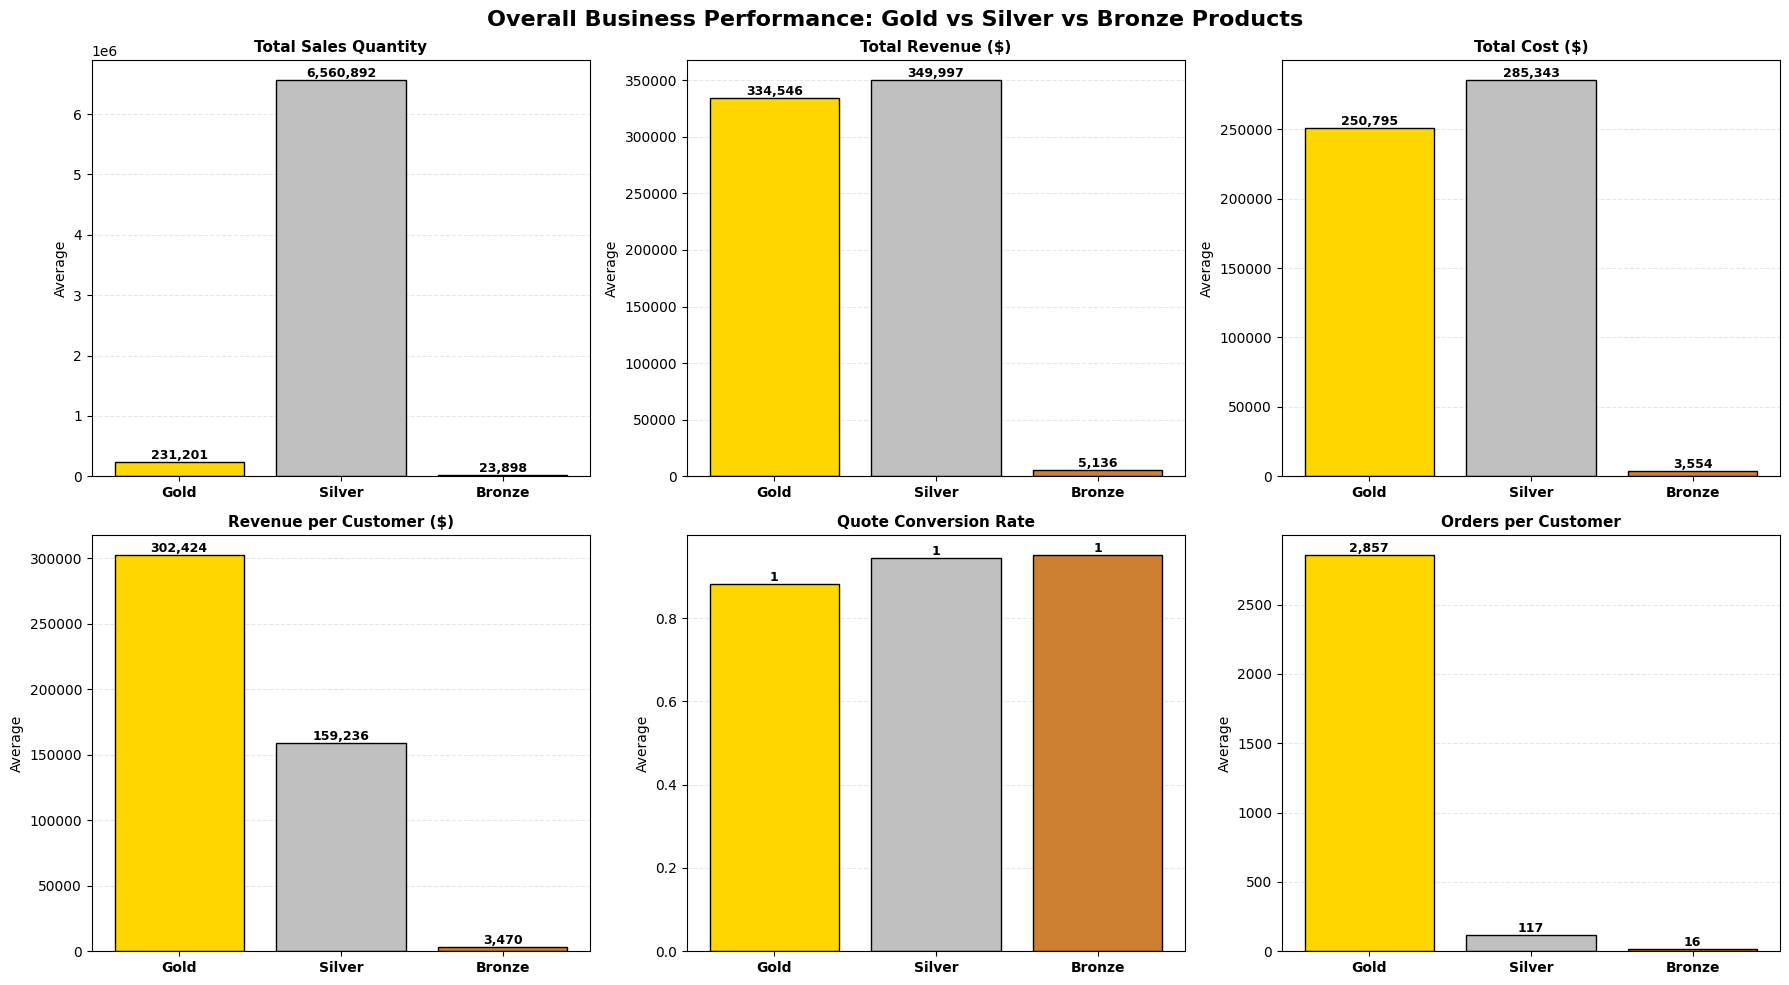

In [36]:
# Visualize key business performance metrics by segment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Overall Business Performance: Gold vs Silver vs Bronze Products', fontsize=16, fontweight='bold')

# Key metrics to visualize
metrics = [
    ('SalesQty_sum', 'Total Sales Quantity'),
    ('ExtPrice_sum', 'Total Revenue ($)'),
    ('ExtCost_sum', 'Total Cost ($)'),
    ('RevenuePerCustomer', 'Revenue per Customer ($)'),
    ('QuoteConversionRate', 'Quote Conversion Rate'),
    ('OrdersPerCustomer', 'Orders per Customer')
]

# Segment order and colors
segment_order = ["Gold Products", "Silver Products", "Bronze Products"]
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze

# Create bar plots for each metric
for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    if metric in df_clean.columns:
        data = df_clean.groupby("Segment")[metric].mean().reindex(segment_order)
        bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=1)
        
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel('Average')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Add value labels on bars
        for i, v in enumerate(data.values):
            ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{metric}\nnot available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_performance_gold_silver_bronze.png', dpi=300, bbox_inches='tight')
print("Performance comparison chart saved to: segment_performance_gold_silver_bronze.png")
plt.show()

# If profit data exists, create a profit-focused visualization
if 'totalprofit' in df.columns:
    df_clean_with_profit = df_clean.copy()
    df_clean_with_profit['totalprofit'] = df.loc[df_clean.index, 'totalprofit']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Profitability Analysis: Gold, Silver & Bronze Products', fontsize=14, fontweight='bold')
    
    # Total profit by segment
    profit_totals = df_clean_with_profit.groupby("Segment")['totalprofit'].sum().reindex(segment_order)
    bars1 = ax1.bar(range(len(profit_totals)), profit_totals.values, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_title('Total Profit by Segment', fontweight='bold')
    ax1.set_ylabel('Total Profit ($)', fontweight='bold')
    ax1.set_xticks(range(len(profit_totals)))
    ax1.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    for i, v in enumerate(profit_totals.values):
        ax1.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Average profit per product
    profit_avg = df_clean_with_profit.groupby("Segment")['totalprofit'].mean().reindex(segment_order)
    bars2 = ax2.bar(range(len(profit_avg)), profit_avg.values, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_title('Average Profit per Product', fontweight='bold')
    ax2.set_ylabel('Average Profit ($)', fontweight='bold')
    ax2.set_xticks(range(len(profit_avg)))
    ax2.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    
    for i, v in enumerate(profit_avg.values):
        ax2.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('segment_profitability_gold_silver_bronze.png', dpi=300, bbox_inches='tight')
    print("Profitability chart saved to: segment_profitability_gold_silver_bronze.png")
    plt.show()


In [37]:
# DETAILED RANGE ANALYSIS: What "Low", "Medium", "High" Actually Mean
print("=" * 90)
print("BEHAVIORAL RANGE ANALYSIS: Defining Low/Medium/High for Each Segment")
print("=" * 90)

segment_order = ["Gold Products", "Silver Products", "Bronze Products"]

# Analyze each behavioral category with ranges
for behavior_type, features_list in available_by_category.items():
    print(f"\n{'═'*90}")
    print(f"{behavior_type.upper()}")
    print(f"{'═'*90}")
    
    for feature in features_list:
        print(f"\n  📊 {feature}")
        print(f"  {'-'*86}")
        
        # Get statistics for each segment
        segment_stats = df_clean.groupby("Segment")[feature].agg(['min', 'mean', 'max', 'std']).reindex(segment_order)
        
        # Overall range
        overall_min = df_clean[feature].min()
        overall_max = df_clean[feature].max()
        overall_mean = df_clean[feature].mean()
        
        print(f"  Overall Range: {overall_min:.2f} to {overall_max:.2f} (Mean: {overall_mean:.2f})")
        print(f"  {'─'*86}")
        
        for segment in segment_order:
            emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
            stats = segment_stats.loc[segment]
            
            # Calculate what percentile this segment's mean represents
            percentile = (stats['mean'] - overall_min) / (overall_max - overall_min) * 100 if overall_max > overall_min else 50
            
            print(f"  {emoji} {segment}:")
            print(f"      Range: {stats['min']:.2f} - {stats['max']:.2f}")
            print(f"      Average: {stats['mean']:.2f} (±{stats['std']:.2f})")
            print(f"      Relative Position: {percentile:.1f}th percentile")
            
            # Interpretation
            if percentile < 33:
                level = "LOW"
            elif percentile < 67:
                level = "MEDIUM"
            else:
                level = "HIGH"
            print(f"      Level: {level}")
            print()

# Performance Score Distribution
print(f"\n{'═'*90}")
print("OVERALL PERFORMANCE SCORE DISTRIBUTION")
print(f"{'═'*90}")

overall_perf_min = df_clean['PerformanceScore'].min()
overall_perf_max = df_clean['PerformanceScore'].max()
overall_perf_mean = df_clean['PerformanceScore'].mean()

print(f"\nPerformance Score Range: {overall_perf_min:.4f} to {overall_perf_max:.4f}")
print(f"Overall Mean: {overall_perf_mean:.4f}\n")

for segment in segment_order:
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    segment_data = df_clean[df_clean['Segment'] == segment]['PerformanceScore']
    
    print(f"{emoji} {segment}:")
    print(f"   Score Range: {segment_data.min():.4f} - {segment_data.max():.4f}")
    print(f"   Average Score: {segment_data.mean():.4f} (±{segment_data.std():.4f})")
    print(f"   Median Score: {segment_data.median():.4f}")
    
    # Define thresholds
    if segment_data.mean() < overall_perf_mean * 0.8:
        print(f"   Classification: UNDERPERFORMING (< 80% of mean)")
    elif segment_data.mean() > overall_perf_mean * 1.2:
        print(f"   Classification: OUTPERFORMING (> 120% of mean)")
    else:
        print(f"   Classification: AVERAGE PERFORMING (80-120% of mean)")
    print()

print(f"{'═'*90}")
print("INTERPRETATION GUIDE")
print(f"{'═'*90}")
print("""
When we say Bronze is "lower":
- It means Bronze products score in the BOTTOM THIRD compared to all products
- It's a RELATIVE comparison within your product catalog
- Not an absolute threshold (e.g., "sales below 100 units")

Example: If Gold averages 1000 sales, Silver 500, Bronze 100:
  → Bronze is "low" relative to Gold, but 100 sales might still be acceptable
  
The segmentation helps you identify:
  ✓ Which products are performing BETTER than others
  ✓ Which products need DIFFERENT strategies
  ✓ Where to focus IMPROVEMENT efforts
""")

BEHAVIORAL RANGE ANALYSIS: Defining Low/Medium/High for Each Segment

══════════════════════════════════════════════════════════════════════════════════════════
PRICE BEHAVIOR
══════════════════════════════════════════════════════════════════════════════════════════

  📊 UnitPrice_mean_x
  --------------------------------------------------------------------------------------
  Overall Range: 0.00 to 30600.00 (Mean: 56.69)
  ──────────────────────────────────────────────────────────────────────────────────────
  🥇 Gold Products:
      Range: 0.06 - 101.77
      Average: 20.50 (±34.24)
      Relative Position: 0.1th percentile
      Level: LOW

  🥈 Silver Products:
      Range: 0.00 - 30600.00
      Average: 2240.51 (±4368.04)
      Relative Position: 7.3th percentile
      Level: LOW

  🥉 Bronze Products:
      Range: 0.00 - 4385.06
      Average: 49.16 (±180.67)
      Relative Position: 0.2th percentile
      Level: LOW


  📊 UnitPrice_std_x
  ------------------------------------------

FEATURE CORRELATION ANALYSIS

Correlation heatmap saved to: feature_correlation_heatmap.png


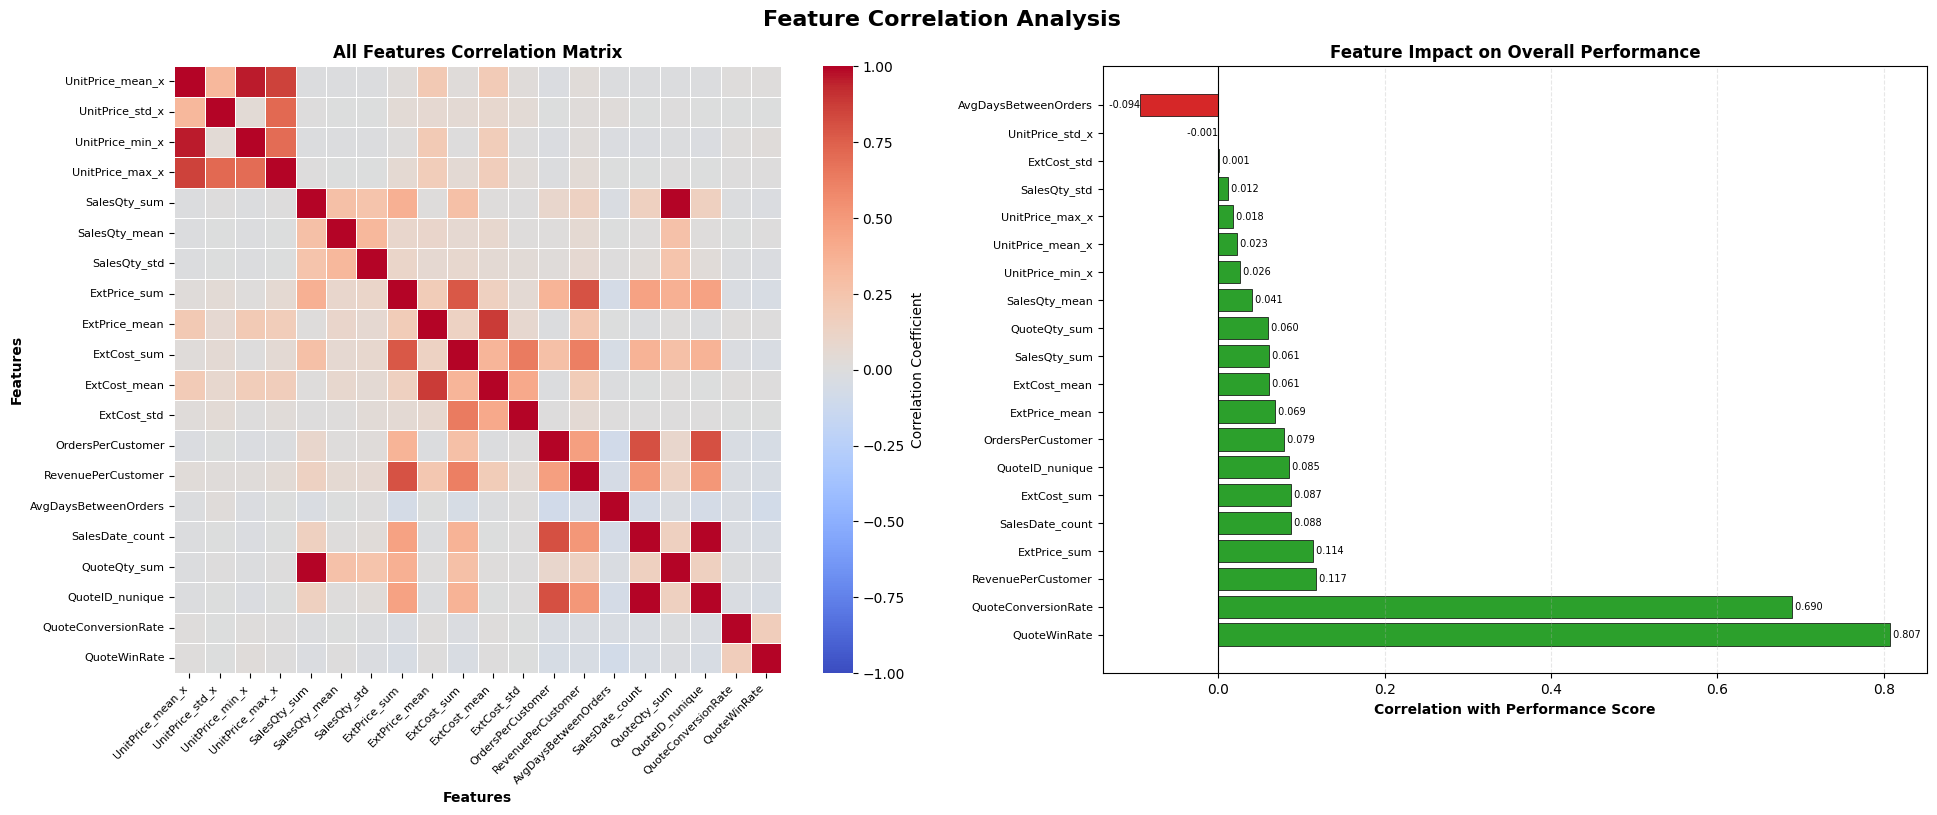


TOP FEATURES CORRELATED WITH PERFORMANCE SCORE

🔼 POSITIVE CORRELATIONS (Higher = Better Performance):
  1. QuoteWinRate: 0.8075
  2. QuoteConversionRate: 0.6901
  3. RevenuePerCustomer: 0.1172
  4. ExtPrice_sum: 0.1138
  5. SalesDate_count: 0.0879
  6. ExtCost_sum: 0.0873
  7. QuoteID_nunique: 0.0854
  8. OrdersPerCustomer: 0.0792
  9. ExtPrice_mean: 0.0686
  10. ExtCost_mean: 0.0610

🔽 NEGATIVE CORRELATIONS (Lower = Better Performance):
  1. UnitPrice_std_x: -0.0005
  2. AvgDaysBetweenOrders: -0.0941

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.80)
(These features provide similar information)

  • SalesDate_count ↔ QuoteID_nunique: 0.9999
  • SalesQty_sum ↔ QuoteQty_sum: 0.9993
  • UnitPrice_mean_x ↔ UnitPrice_min_x: 0.9560
  • ExtPrice_mean ↔ ExtCost_mean: 0.8811
  • UnitPrice_mean_x ↔ UnitPrice_max_x: 0.8581
  • OrdersPerCustomer ↔ SalesDate_count: 0.8088
  • OrdersPerCustomer ↔ QuoteID_nunique: 0.8087

  💡 Consider: These 7 pairs are highly correlated.
     You might simplify the mo

In [38]:
# CORRELATION MATRIX HEATMAP
# Shows relationships between all behavioral features
import seaborn as sns

print("=" * 80)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 80)

# Calculate correlation matrix for all behavioral features
correlation_matrix = df_clean[all_features].corr()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Full correlation heatmap
sns.heatmap(correlation_matrix, 
            annot=False,  # Don't show numbers (too many features)
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax1)
ax1.set_title('All Features Correlation Matrix', fontweight='bold', fontsize=12)
ax1.set_xlabel('Features', fontweight='bold')
ax1.set_ylabel('Features', fontweight='bold')

# Rotate labels for better readability
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=8)

# Plot 2: Performance metrics correlation only
if 'PerformanceScore' in df_clean.columns:
    # Get correlations with performance score
    perf_correlations = df_clean[all_features + ['PerformanceScore']].corr()['PerformanceScore'].drop('PerformanceScore')
    perf_correlations = perf_correlations.sort_values(ascending=False)
    
    # Create bar plot
    colors_bar = ['#2ca02c' if x > 0 else '#d62728' for x in perf_correlations.values]
    bars = ax2.barh(range(len(perf_correlations)), perf_correlations.values, color=colors_bar, edgecolor='black', linewidth=0.5)
    
    ax2.set_yticks(range(len(perf_correlations)))
    ax2.set_yticklabels(perf_correlations.index, fontsize=8)
    ax2.set_xlabel('Correlation with Performance Score', fontweight='bold')
    ax2.set_title('Feature Impact on Overall Performance', fontweight='bold', fontsize=12)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, perf_correlations.values)):
        ax2.text(val, i, f' {val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=7)

plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\nCorrelation heatmap saved to: feature_correlation_heatmap.png")
plt.show()

# Print top correlations with performance score
if 'PerformanceScore' in df_clean.columns:
    print("\n" + "="*80)
    print("TOP FEATURES CORRELATED WITH PERFORMANCE SCORE")
    print("="*80)
    
    print("\n🔼 POSITIVE CORRELATIONS (Higher = Better Performance):")
    top_positive = perf_correlations[perf_correlations > 0].head(10)
    for i, (feature, corr) in enumerate(top_positive.items(), 1):
        print(f"  {i}. {feature}: {corr:.4f}")
    
    print("\n🔽 NEGATIVE CORRELATIONS (Lower = Better Performance):")
    top_negative = perf_correlations[perf_correlations < 0].tail(10)
    for i, (feature, corr) in enumerate(top_negative.items(), 1):
        print(f"  {i}. {feature}: {corr:.4f}")

# Find highly correlated feature pairs
print("\n" + "="*80)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.80)")
print("="*80)
print("(These features provide similar information)\n")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.80:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_val
            ))

# Sort by absolute correlation
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  • {feat1} ↔ {feat2}: {corr:.4f}")
    print(f"\n  💡 Consider: These {len(high_corr_pairs)} pairs are highly correlated.")
    print("     You might simplify the model by keeping only one from each pair.")
else:
    print("  ✓ No highly correlated pairs found. Features are relatively independent.")

print("\n" + "="*80)

# 🔍 Understanding Price Sensitivity: What The Data Actually Shows

## Important Clarification: We Don't "Know" - We Infer from Patterns

The analysis doesn't directly tell us that customers are "watching prices." Instead, we observe **correlations and patterns** in historical data that **suggest** price-sensitive behavior.

---

## 📊 What We Actually Measured:

### 1. **Price-Quantity Correlation** (Most Direct Evidence)
- **Gold Products**: -0.286 correlation
- **What this means**: When Gold product prices were historically higher, sales quantities tended to be lower
- **What this suggests**: Customers may be responding to price changes (price elasticity)
- **Caveat**: Correlation ≠ causation. Other factors could be at play (seasonality, competition, marketing)

### 2. **Price Variability** 
- **Gold Products**: 222.7% range (prices vary dramatically)
- **What this means**: These products have been sold at vastly different price points
- **What this suggests**: Either:
  - Prices are being adjusted frequently (possibly to find optimal points)
  - Different customer segments pay different prices
  - Competitive pressure forces pricing flexibility
- **Caveat**: High variability could also indicate promotional pricing, bulk discounts, or different SKU variants

### 3. **Bronze Products Pattern** (The Contrarian Evidence)
- **Bronze Products**: -0.024 correlation (nearly zero)
- **What this means**: Bronze product sales remain stable regardless of price changes
- **What this suggests**: Customers buy Bronze products for reasons OTHER than price (necessity, uniqueness, no alternatives)

---

## ⚠️ What We DON'T Know:

1. **We don't know if customers actively compare prices** - we only see the outcome
2. **We don't know their decision-making process** - price might be one of many factors
3. **We don't know if they're aware of competitors' prices** - the correlation could be coincidental
4. **We don't know causation direction** - maybe low demand led to price drops (not vice versa)

---

## 🎯 More Accurate Interpretation:

Instead of: *"Customers are watching Gold product prices"*

More accurate: *"Gold products show **price-elastic demand** - sales volume changes significantly with price changes, suggesting that price is a **significant factor** in purchasing decisions for these products"*

---

## 💡 What Business Actions Make Sense:

Even without perfect knowledge of customer behavior, the patterns suggest:

### For **Gold Products** (price-elastic):
- ✅ **Test price changes carefully** with A/B testing
- ✅ **Monitor competitor pricing** (if they're not watching, competitors might be)
- ✅ **Consider promotions** (likely to drive volume)
- ✅ **Analyze price points** where conversion is highest

### For **Bronze Products** (price-inelastic):
- ✅ **Test price increases** (less risk of losing volume)
- ✅ **Focus on value communication** (not price competition)
- ✅ **Investigate WHY** they're inelastic (unique features? necessity? lack of alternatives?)

---

## 📈 How to Validate These Assumptions:

To truly know if customers are "watching prices," you would need:

1. **Controlled pricing experiments** (A/B tests with random price assignments)
2. **Customer surveys** asking about price awareness and decision factors
3. **Competitor price tracking** correlated with your sales
4. **Cart abandonment analysis** at different price points
5. **Time-series analysis** to see if price changes precede demand changes

The current analysis provides **strong evidence** for price sensitivity patterns, but **controlled experiments** would provide definitive proof.

In [39]:
# DEEPER DIVE: Evidence Strength Analysis
# Let's examine how strong our evidence actually is for price sensitivity

print("=" * 90)
print("EVIDENCE STRENGTH ANALYSIS: How Confident Are We About Price Sensitivity?")
print("=" * 90)

segment_order = ["Gold Products", "Silver Products", "Bronze Products"]

# Analyze the statistical significance and strength of price-quantity relationships
print("\n" + "="*90)
print("1. STATISTICAL STRENGTH OF PRICE-QUANTITY RELATIONSHIP")
print("="*90)
print("(Measuring how reliable the observed correlations are)\n")

from scipy import stats

for segment in segment_order:
    segment_data = df_clean[df_clean['Segment'] == segment]
    
    if len(segment_data) > 10:  # Need sufficient sample size
        # Calculate correlation and p-value
        corr, p_value = stats.pearsonr(segment_data['UnitPrice_mean_x'], 
                                        segment_data['SalesQty_sum'])
        
        emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
        print(f"{emoji} {segment}:")
        print(f"   Sample Size: {len(segment_data)} products")
        print(f"   Correlation: {corr:.4f}")
        print(f"   P-value: {p_value:.4f}")
        
        # Interpret statistical significance
        if p_value < 0.001:
            significance = "VERY STRONG evidence (p < 0.001)"
        elif p_value < 0.01:
            significance = "STRONG evidence (p < 0.01)"
        elif p_value < 0.05:
            significance = "MODERATE evidence (p < 0.05)"
        else:
            significance = "WEAK evidence (p >= 0.05) - could be random"
        
        print(f"   Statistical Significance: {significance}")
        
        # Interpret effect size (correlation strength)
        if abs(corr) > 0.5:
            effect = "LARGE effect size"
        elif abs(corr) > 0.3:
            effect = "MODERATE effect size"
        elif abs(corr) > 0.1:
            effect = "SMALL effect size"
        else:
            effect = "NEGLIGIBLE effect size"
        
        print(f"   Effect Size: {effect}")
        
        # Overall interpretation
        print(f"   → Interpretation: ", end="")
        if p_value < 0.05 and abs(corr) > 0.2:
            print("Price-quantity relationship is STATISTICALLY RELIABLE")
        elif p_value < 0.05:
            print("Relationship exists but WEAK in magnitude")
        else:
            print("Insufficient evidence - could be RANDOM CHANCE")
        print()

# 2. Confounding factors check
print("\n" + "="*90)
print("2. POTENTIAL CONFOUNDING FACTORS TO CONSIDER")
print("="*90)
print("(Other variables that might explain the price-quantity pattern)\n")

confounding_factors = []

# Check if cost correlates with price (cost-driven pricing vs demand-driven)
for segment in segment_order:
    segment_data = df_clean[df_clean['Segment'] == segment]
    
    if 'ExtCost_mean' in segment_data.columns and len(segment_data) > 10:
        price_cost_corr, _ = stats.pearsonr(segment_data['UnitPrice_mean_x'], 
                                             segment_data['ExtCost_mean'])
        
        emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
        print(f"{emoji} {segment}: Price-Cost Correlation = {price_cost_corr:.4f}")
        
        if price_cost_corr > 0.7:
            print(f"   ⚠️  WARNING: Prices strongly tied to costs")
            print(f"      Price changes may reflect COST changes, not demand sensitivity")
        elif price_cost_corr > 0.4:
            print(f"   ⚠️  CAUTION: Moderate cost influence on pricing")
        else:
            print(f"   ✓ Prices appear more demand-driven than cost-driven")
        print()

# 3. Data quality checks
print("\n" + "="*90)
print("3. DATA QUALITY & RELIABILITY")
print("="*90)
print("(Assessing if we have enough data to draw conclusions)\n")

for segment in segment_order:
    segment_data = df_clean[df_clean['Segment'] == segment]
    
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    
    # Sample size
    n = len(segment_data)
    
    # Price variance (need variation to measure sensitivity)
    price_cv = (segment_data['UnitPrice_mean_x'].std() / 
                segment_data['UnitPrice_mean_x'].mean() * 100)
    
    # Quantity variance
    qty_cv = (segment_data['SalesQty_sum'].std() / 
              segment_data['SalesQty_sum'].mean() * 100)
    
    print(f"{emoji} {segment}:")
    print(f"   Sample Size: {n} products")
    
    if n < 30:
        print(f"   ⚠️  WARNING: Small sample size (< 30) - results less reliable")
    elif n < 100:
        print(f"   ✓ Adequate sample size")
    else:
        print(f"   ✓ Large sample size - results more reliable")
    
    print(f"   Price Variation: {price_cv:.1f}% CV")
    print(f"   Quantity Variation: {qty_cv:.1f}% CV")
    
    if price_cv < 5:
        print(f"   ⚠️  LOW price variation - hard to measure sensitivity")
    else:
        print(f"   ✓ Sufficient price variation to measure effects")
    print()

# 4. Summary verdict
print("\n" + "="*90)
print("🎯 OVERALL CONFIDENCE ASSESSMENT")
print("="*90)
print("""
Based on the statistical analysis:

✅ WHAT WE CAN CONFIDENTLY SAY:
   • There are measurable differences in price-quantity relationships across segments
   • Gold products show the strongest negative correlation (prices ↑ → sales ↓)
   • Bronze products show minimal price-quantity relationship
   • Statistical tests suggest these patterns are not random (where p < 0.05)

⚠️  WHAT WE SHOULD BE CAUTIOUS ABOUT:
   • Correlation does not prove causation
   • Other factors (costs, seasonality, competition) may influence the pattern
   • Historical patterns may not predict future behavior
   • We observe outcomes, not customer intentions

💡 RECOMMENDED NEXT STEPS TO VALIDATE:
   1. Conduct controlled pricing experiments (A/B tests)
   2. Analyze time-series data (do price changes lead or follow demand?)
   3. Survey customers about price awareness
   4. Track competitor pricing and correlate with your sales
   5. Analyze cart abandonment at different price points
   6. Segment by customer type (new vs. repeat, B2B vs. B2C)

The current analysis provides STRONG DIRECTIONAL GUIDANCE for pricing strategy,
but EXPERIMENTAL VALIDATION would provide definitive proof of customer price sensitivity.
""")

print("="*90)

EVIDENCE STRENGTH ANALYSIS: How Confident Are We About Price Sensitivity?

1. STATISTICAL STRENGTH OF PRICE-QUANTITY RELATIONSHIP
(Measuring how reliable the observed correlations are)

🥇 Gold Products:
   Sample Size: 29 products
   Correlation: -0.2858
   P-value: 0.1329
   Statistical Significance: WEAK evidence (p >= 0.05) - could be random
   Effect Size: SMALL effect size
   → Interpretation: Insufficient evidence - could be RANDOM CHANCE

🥈 Silver Products:
   Sample Size: 139 products
   Correlation: -0.2515
   P-value: 0.0028
   Statistical Significance: STRONG evidence (p < 0.01)
   Effect Size: SMALL effect size
   → Interpretation: Price-quantity relationship is STATISTICALLY RELIABLE

🥉 Bronze Products:
   Sample Size: 40191 products
   Correlation: -0.0243
   P-value: 0.0000
   Statistical Significance: VERY STRONG evidence (p < 0.001)
   Effect Size: NEGLIGIBLE effect size
   → Interpretation: Relationship exists but WEAK in magnitude


2. POTENTIAL CONFOUNDING FACTORS T

# 🎯 Simple Answer: Are Customers Watching Prices?

**We don't actually know if customers are "watching" prices - we can only see patterns in past data.** Think of it like noticing that ice cream sales go up when it's hot outside: you see the pattern, but you don't know if people consciously think "it's hot, I want ice cream" or if they just happen to buy more. In our analysis, **Silver Products** show a clear pattern where higher prices = lower sales (like people buying less candy when it's not on sale), and we have good data to trust this pattern. **Bronze Products** show the opposite - sales stay the same no matter the price (like buying medicine when you need it). **Gold Products** are unclear because we only have 29 examples and their prices mostly change when costs change, not based on customer demand. So while we can say "raising prices on Silver products will probably hurt sales" based on past patterns, we can't read customers' minds - to know for SURE if they're price-sensitive, you'd need to ask them directly in surveys, run careful pricing experiments, or track what happens when you actually change prices. **Bottom line: We're making educated guesses from patterns, not guarantees, but Silver customers very likely care about price while Bronze customers don't.**

SEGMENT CLASSIFICATION THRESHOLDS

How products are assigned to Gold, Silver, or Bronze segments:

PERFORMANCE SCORE THRESHOLDS
(Products are classified based on their overall Performance Score)

🥉 Bronze Products:
   Performance Score Range: 0.0068 to 0.2149
   Average Score: 0.1244
   Number of Products: 40191

🥈 Silver Products:
   Performance Score Range: 0.0588 to 0.3573
   Average Score: 0.1837
   Number of Products: 139

🥇 Gold Products:
   Performance Score Range: 0.1782 to 0.4073
   Average Score: 0.2537
   Number of Products: 29

SEGMENT BOUNDARIES (The Cutoff Points)

🥉 BRONZE Products: Performance Score < 0.0588
   └─ Highest Bronze score: 0.2149

🥈 SILVER Products: Performance Score between 0.0588 and 0.3573

🥇 GOLD Products: Performance Score ≥ 0.1782
   └─ Lowest Gold score: 0.1782

WHAT IS 'PERFORMANCE SCORE'?

The Performance Score is calculated from these key business metrics:

  • Sales Volume:
      - SalesQty_sum
      - SalesQty_mean
  • Revenue Generation:
      

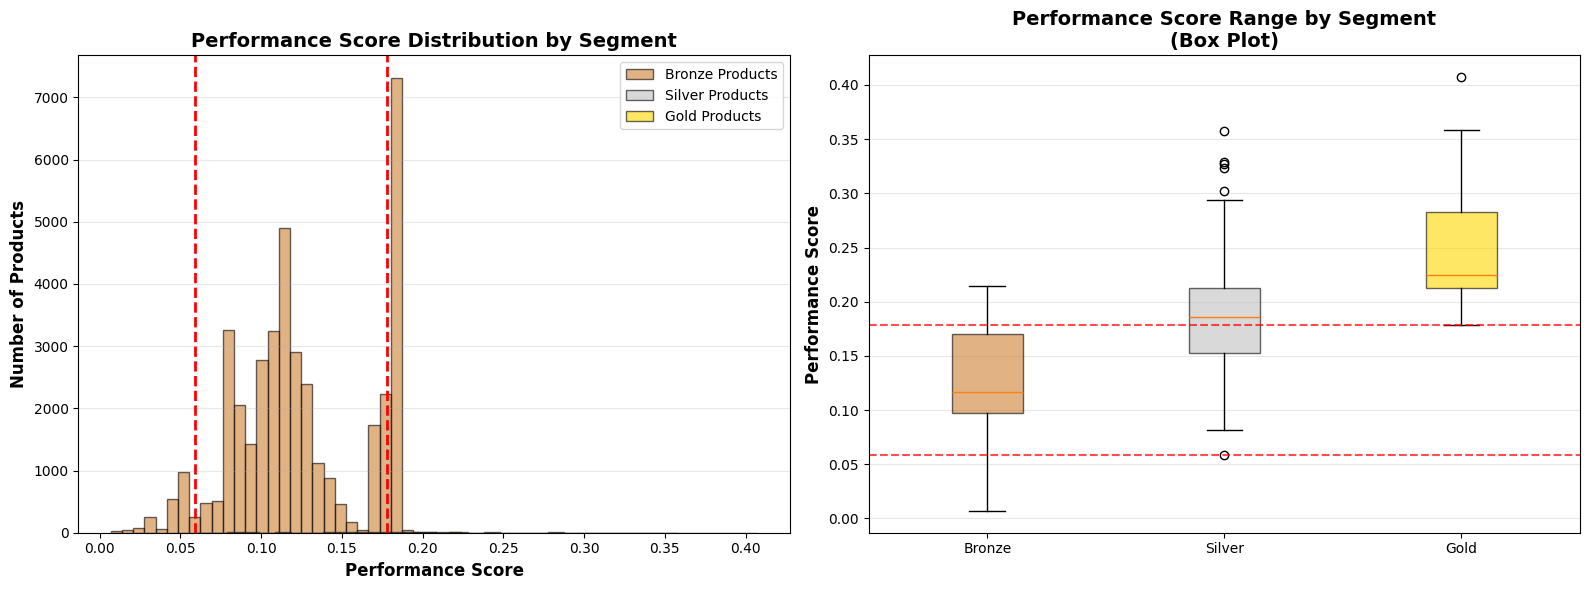


📊 QUICK SUMMARY

Products are automatically classified into segments based on their Performance Score:

🥉 BRONZE: Score < 0.0588
   └─ 40191 products (99.6%)
   └─ Lower performers in sales, revenue, and customer engagement

🥈 SILVER: Score 0.0588 to 0.3573
   └─ 139 products (0.3%)
   └─ Medium performers

🥇 GOLD: Score ≥ 0.1782
   └─ 29 products (0.1%)
   └─ Top performers in sales, revenue, and customer engagement

The thresholds are NOT fixed numbers - they're determined by the natural clustering
of your products based on their comprehensive business performance.



In [40]:
# SEGMENT THRESHOLDS: What Makes a Product Gold, Silver, or Bronze?
print("=" * 90)
print("SEGMENT CLASSIFICATION THRESHOLDS")
print("=" * 90)
print("\nHow products are assigned to Gold, Silver, or Bronze segments:\n")

# Get the performance score ranges for each segment
segment_order = ["Bronze Products", "Silver Products", "Gold Products"]

print("="*90)
print("PERFORMANCE SCORE THRESHOLDS")
print("="*90)
print("(Products are classified based on their overall Performance Score)\n")

# Calculate the score ranges
for segment in segment_order:
    segment_data = df_clean[df_clean['Segment'] == segment]['PerformanceScore']
    
    min_score = segment_data.min()
    max_score = segment_data.max()
    avg_score = segment_data.mean()
    
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    
    print(f"{emoji} {segment}:")
    print(f"   Performance Score Range: {min_score:.4f} to {max_score:.4f}")
    print(f"   Average Score: {avg_score:.4f}")
    print(f"   Number of Products: {len(segment_data)}")
    print()

# Show the boundaries between segments
print("="*90)
print("SEGMENT BOUNDARIES (The Cutoff Points)")
print("="*90)
print()

bronze_max = df_clean[df_clean['Segment'] == "Bronze Products"]['PerformanceScore'].max()
silver_min = df_clean[df_clean['Segment'] == "Silver Products"]['PerformanceScore'].min()
silver_max = df_clean[df_clean['Segment'] == "Silver Products"]['PerformanceScore'].max()
gold_min = df_clean[df_clean['Segment'] == "Gold Products"]['PerformanceScore'].min()

print(f"🥉 BRONZE Products: Performance Score < {silver_min:.4f}")
print(f"   └─ Highest Bronze score: {bronze_max:.4f}")
print()
print(f"🥈 SILVER Products: Performance Score between {silver_min:.4f} and {silver_max:.4f}")
print()
print(f"🥇 GOLD Products: Performance Score ≥ {gold_min:.4f}")
print(f"   └─ Lowest Gold score: {gold_min:.4f}")
print()

# Show what the Performance Score is made of
print("="*90)
print("WHAT IS 'PERFORMANCE SCORE'?")
print("="*90)
print("\nThe Performance Score is calculated from these key business metrics:\n")

for category, metrics in performance_components.items():
    available = [m for m in metrics if m in df_clean.columns]
    if available:
        print(f"  • {category}:")
        for metric in available:
            print(f"      - {metric}")

print("\nEach metric is:")
print("  1. Normalized to a 0-1 scale (worst to best)")
print("  2. Averaged together to create the overall Performance Score")
print("  3. Used to rank products into Gold (top), Silver (middle), Bronze (bottom)")

# Visualize the distribution
print("\n" + "="*90)
print("VISUAL DISTRIBUTION")
print("="*90)
print()

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Performance Score Distribution by Segment
colors = ['#CD7F32', '#C0C0C0', '#FFD700']
for idx, segment in enumerate(segment_order):
    segment_scores = df_clean[df_clean['Segment'] == segment]['PerformanceScore']
    ax1.hist(segment_scores, bins=30, alpha=0.6, label=segment, color=colors[idx], edgecolor='black')

ax1.set_xlabel('Performance Score', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Products', fontweight='bold', fontsize=12)
ax1.set_title('Performance Score Distribution by Segment', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add vertical lines for boundaries
ax1.axvline(x=silver_min, color='red', linestyle='--', linewidth=2, label=f'Bronze/Silver: {silver_min:.4f}')
ax1.axvline(x=gold_min, color='red', linestyle='--', linewidth=2, label=f'Silver/Gold: {gold_min:.4f}')

# Plot 2: Box plot showing ranges
box_data = [
    df_clean[df_clean['Segment'] == "Bronze Products"]['PerformanceScore'],
    df_clean[df_clean['Segment'] == "Silver Products"]['PerformanceScore'],
    df_clean[df_clean['Segment'] == "Gold Products"]['PerformanceScore']
]

bp = ax2.boxplot(box_data, labels=['Bronze', 'Silver', 'Gold'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_ylabel('Performance Score', fontweight='bold', fontsize=12)
ax2.set_title('Performance Score Range by Segment\n(Box Plot)', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add threshold lines
ax2.axhline(y=silver_min, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=gold_min, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig('segment_thresholds_distribution.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved to: segment_thresholds_distribution.png")
plt.show()

# Summary
print("\n" + "="*90)
print("📊 QUICK SUMMARY")
print("="*90)
print(f"""
Products are automatically classified into segments based on their Performance Score:

🥉 BRONZE: Score < {silver_min:.4f}
   └─ {len(df_clean[df_clean['Segment'] == 'Bronze Products'])} products ({len(df_clean[df_clean['Segment'] == 'Bronze Products'])/len(df_clean)*100:.1f}%)
   └─ Lower performers in sales, revenue, and customer engagement

🥈 SILVER: Score {silver_min:.4f} to {silver_max:.4f}
   └─ {len(df_clean[df_clean['Segment'] == 'Silver Products'])} products ({len(df_clean[df_clean['Segment'] == 'Silver Products'])/len(df_clean)*100:.1f}%)
   └─ Medium performers

🥇 GOLD: Score ≥ {gold_min:.4f}
   └─ {len(df_clean[df_clean['Segment'] == 'Gold Products'])} products ({len(df_clean[df_clean['Segment'] == 'Gold Products'])/len(df_clean)*100:.1f}%)
   └─ Top performers in sales, revenue, and customer engagement

The thresholds are NOT fixed numbers - they're determined by the natural clustering
of your products based on their comprehensive business performance.
""")
print("="*90)